In [1]:
import random
from functools import reduce
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Vocab: Numeric tokens 0..12 plus '*' and '='
vocab = [str(i) for i in range(13)] + ['*', '=']
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for i, ch in enumerate(vocab)}


In [4]:
# Model
class MultLearner(nn.Module):
    def __init__(self, rank=8):
        super().__init__()
        self.vocab_size = len(vocab)           # 15 here: 0..12, '*', '='
        self.embed_dim = 32

        # Embedding for tokens
        self.embed = nn.Embedding(self.vocab_size, self.embed_dim)

        # Architect maps *input token* embedding -> operator descriptor z
        self.architect = nn.Sequential(
            nn.Linear(self.embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, rank)  # z depends only on input token
        )

        # Low-rank factors (learnable)
        self.L = nn.Parameter(torch.randn(self.vocab_size, rank) * 0.1)
        self.R = nn.Parameter(torch.randn(self.vocab_size, rank) * 0.1)

    def get_transition_matrix(self, n1, n2):
        """
        Return W_logits shaped (B, V_src, V_tgt).
        Important: operator descriptor z computed from n2 only.
        """
        # n1 kept for API compatibility (not used to compute z)
        # n2: tensor of shape (B,) containing indices of input token (the multiplier)
        if n2.dim() == 0:
            n2 = n2.unsqueeze(0)
        e2 = self.embed(n2.to(self.device()))   # (B, embed_dim)
        z = self.architect(e2)                  # (B, rank)

        # Build low-rank operator batch: 'br, vr, wr -> b v w'
        W_logits = torch.einsum('br, vr, wr -> bvw', z, self.L, self.R)
        return W_logits

    def forward(self, x):
        # x expected shape (B, seq_len) with left at col 0 and input at col 2
        return self.get_transition_matrix(x[:, 0], x[:, 2])

    def device(self):
        return next(self.parameters()).device

In [5]:
# data
full_data = [f"{i} * {j} ={(i*j) % 13}" for i in range(1, 13) for j in range(1, 13)]
random.seed(42)
random.shuffle(full_data)
split_idx = int(0.8 * len(full_data))
train_data = full_data[:split_idx]
test_data = full_data[split_idx:]

print(f"Train pairs: {len(train_data)}, Test pairs: {len(test_data)}")
# sample print
print("Sample train examples:", train_data[:4])

Train pairs: 115, Test pairs: 29
Sample train examples: ['4 * 6 =11', '12 * 1 =12', '8 * 9 =7', '5 * 4 =7']


In [6]:
def encode(data_list, device=device):
    tensor_list = []
    targets_list = []
    for eq in data_list:
        # left token, '*' , right token, '='  are separated by spaces in your format
        # example "3 * 5 =15" but here text is e.g. "3 * 5 =2"
        left_part = eq[:eq.find("=")+1].split()   # ['3', '*', '5', '=']
        seq = [stoi[c] for c in left_part]
        # target substring after '='
        target_str = eq[eq.find("=")+1:]
        # ensure no stray whitespace
        target_str = target_str.strip()
        target = stoi[target_str]
        tensor_list.append(torch.tensor(seq, dtype=torch.long))
        targets_list.append(torch.tensor(target, dtype=torch.long))
    return torch.stack(tensor_list).to(device), torch.stack(targets_list).to(device)

train_x, train_y = encode(train_data, device=device)
test_x, test_y = encode(test_data, device=device)

In [7]:
model = MultLearner(rank=16).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

epochs = 8000
print(f"Training for {epochs} epochs on {len(train_x)} examples...")

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    T_logits = model(train_x)  # shape (B, V_src, V_tgt)

    batch_idx = torch.arange(train_x.size(0), device=device)
    src_indices = train_x[:, 0]  # left operand index for each example (n1)
    # final_jump[b, :] is the distribution produced by applying operator for input to one-hot(src_indices[b])
    final_jump = T_logits[batch_idx, src_indices, :]  # shape (B, V_tgt)

    loss = F.cross_entropy(final_jump, train_y)
    loss.backward()
    optimizer.step()

    if epoch % 250 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}: Loss {loss.item():.6f}")

# optional, uncomment to save
# torch.save(model.state_dict(), "group13.pth")

Training for 8000 epochs on 115 examples...
Epoch 0: Loss 2.707893
Epoch 250: Loss 0.000861
Epoch 500: Loss 0.001019
Epoch 750: Loss 0.000950
Epoch 1000: Loss 0.000858
Epoch 1250: Loss 0.000765
Epoch 1500: Loss 0.000699
Epoch 1750: Loss 0.000649
Epoch 2000: Loss 0.000610
Epoch 2250: Loss 0.000582
Epoch 2500: Loss 0.000561
Epoch 2750: Loss 0.000546
Epoch 3000: Loss 0.000534
Epoch 3250: Loss 0.000525
Epoch 3500: Loss 0.000517
Epoch 3750: Loss 0.000510
Epoch 4000: Loss 0.000504
Epoch 4250: Loss 0.000498
Epoch 4500: Loss 0.000493
Epoch 4750: Loss 0.000489
Epoch 5000: Loss 0.000487
Epoch 5250: Loss 0.000485
Epoch 5500: Loss 0.000484
Epoch 5750: Loss 0.000484
Epoch 6000: Loss 0.000484
Epoch 6250: Loss 0.000484
Epoch 6500: Loss 0.000483
Epoch 6750: Loss 0.000484
Epoch 7000: Loss 0.000482
Epoch 7250: Loss 0.000481
Epoch 7500: Loss 0.000474
Epoch 7750: Loss 0.000473
Epoch 7999: Loss 0.000473


In [8]:
# try some test example. Model never learns these samples, can they infer the rule of multiplication?
model.eval()
with torch.no_grad():
    T_logits = model(test_x)
    batch_idx = torch.arange(test_x.size(0), device=device)
    src_indices = test_x[:, 0]
    final_jump = T_logits[batch_idx, src_indices, :]
    preds = final_jump.argmax(dim=1)
    correct = (preds == test_y).sum().item()
    total = len(test_y)
    acc = correct / total * 100
    print(f"\nPairwise accuracy on held-out pairs: {correct}/{total} ({acc:.1f}%)")

    # show some examples
    print("Examples:")
    for i in range(8):
        seq_tokens = [itos[idx.item()] for idx in test_x[i]]
        pred = itos[preds[i].item()]
        truth = itos[test_y[i].item()]
        print(f"  {''.join(seq_tokens)} -> pred {pred} (true {truth}) {'OK' if pred == truth else 'ERR'}")


Pairwise accuracy on held-out pairs: 29/29 (100.0%)
Examples:
  1*1= -> pred 1 (true 1) OK
  10*4= -> pred 1 (true 1) OK
  9*8= -> pred 7 (true 7) OK
  12*7= -> pred 6 (true 6) OK
  7*4= -> pred 2 (true 2) OK
  12*8= -> pred 5 (true 5) OK
  12*12= -> pred 1 (true 1) OK
  5*6= -> pred 4 (true 4) OK


In [9]:
# -------------------------
# Inference helpers: soft propagation (no argmax collapse)
# -------------------------
def apply_operator_soft(psi, input_val_idx, model):
    """
    psi: 1D torch tensor length V (soft distribution over source tokens)
    input_val_idx: int (vocab index for multiplier token)
    Returns new psi (soft) after applying operator for input_val_idx.
    """
    model.eval()
    with torch.no_grad():
        n2 = torch.tensor([input_val_idx], device=model.device())
        # get batch of size 1 transition logits
        T_logits = model.get_transition_matrix(n1=torch.tensor([0], device=model.device()), n2=n2)  # (1, V_src, V_tgt)
        T = F.softmax(T_logits[0], dim=1).to("cuda")  # rows sum to 1: source -> distribution over targets
        psi_row = psi.unsqueeze(0).to("cuda")         # (1, V_src)
        psi_next = psi_row @ T             # (1, V_tgt)
        return psi_next.squeeze(0).cpu()

In [10]:
# let's test different chain of multiplications
def stress_test_chain(model, chain_length=5, seed=0):
    random.seed(seed)
    chain = [random.randint(1, 12) for _ in range(chain_length)]
    expected = reduce(lambda x, y: (x * y) % 13, chain, 1)
    print(f"\nStress test chain length {chain_length}: {' * '.join(map(str, chain))} -> expected {expected}")

    # initialize psi as one-hot at '1' (neutral)
    psi = torch.zeros(len(vocab))
    psi[stoi['1']] = 1.0

    # propagate each multiplier
    for num in chain:
        input_idx = stoi[str(num)]
        psi = apply_operator_soft(psi, input_idx, model)

    pred_idx = psi.argmax().item()
    conf = psi.max().item()
    pred_val = int(itos[pred_idx])
    print(f"  Model prediction: {pred_val} (conf {conf:.3f}) -> {'OK' if pred_val == expected else 'FAIL'}")
    return pred_val == expected


In [11]:
for L in (5, 10):
    _ = stress_test_chain(model, chain_length=L, seed=42)


Stress test chain length 5: 11 * 2 * 1 * 12 * 5 -> expected 7
  Model prediction: 7 (conf 0.998) -> OK

Stress test chain length 10: 11 * 2 * 1 * 12 * 5 * 4 * 4 * 3 * 12 * 2 -> expected 4
  Model prediction: 4 (conf 0.993) -> OK


In [12]:
# -------------------------
# Benchmark generalization over lengths using soft propagation
# -------------------------
def benchmark_generalization(model, max_len=20, trials=100):
    print("\nBenchmarking generalization (soft propagation):")
    print(f"{'Length':<8} | {'Accuracy':<10} | {'Mean Conf':<10}")
    print("-" * 36)
    results = []
    for L in range(2, max_len + 1, 2):
        correct = 0
        conf_sum = 0.0
        for t in range(trials):
            chain = [random.randint(1, 12) for _ in range(L)]
            true_val = reduce(lambda x, y: (x * y) % 13, chain, 1)
            # run physics
            psi = torch.zeros(len(vocab))
            psi[stoi['1']] = 1.0
            current_conf = 1.0
            for num in chain:
                psi = apply_operator_soft(psi, stoi[str(num)], model)
                current_conf *= psi.max().item()
            pred_idx = psi.argmax().item()
            if int(itos[pred_idx]) == true_val:
                correct += 1
            conf_sum += current_conf
        acc = (correct / trials) * 100
        mean_conf = conf_sum / trials
        print(f"{L:<8} | {acc:6.2f}%   | {mean_conf:.4f}")
        results.append((L, acc, mean_conf))
    return results

gen_results = benchmark_generalization(model, max_len=20, trials=200)


Benchmarking generalization (soft propagation):
Length   | Accuracy   | Mean Conf 
------------------------------------
2        | 100.00%   | 0.9973
4        | 100.00%   | 0.9913
6        | 100.00%   | 0.9808
8        | 100.00%   | 0.9686
10       | 100.00%   | 0.9514
12       | 100.00%   | 0.9365
14       | 100.00%   | 0.9088
16       | 100.00%   | 0.8905
18       | 100.00%   | 0.8606
20       | 100.00%   | 0.8326


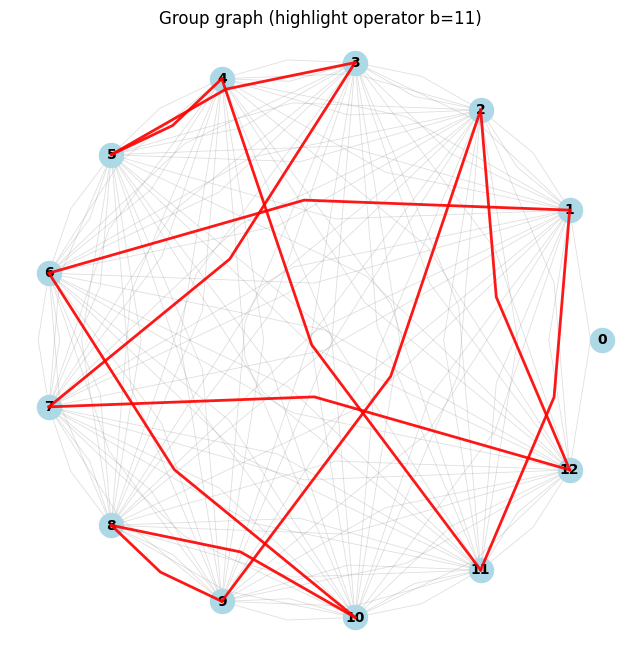

In [14]:
import numpy as np
# plot connection with highlight in O_11 operator

def get_numeric_ops(model, temp=1.0):
    """Return a dict b -> operator matrix (13x13 numpy) for numeric tokens."""
    ops = {}
    with torch.no_grad():
        for b in range(1, 13):  # skip b=0 as operator choice if you like
            n2 = torch.tensor([stoi[str(b)]], device=device)
            W_logits = model.get_transition_matrix(n1=torch.tensor([0], device=device), n2=n2)[0]  # (V_src, V_tgt)
            T = torch.softmax(W_logits / (temp+1e-12), dim=1)[:13, :13].cpu().numpy()  # numeric block
            ops[b] = T
    return ops

def plot_group_graph_all_ops(ops, highlight_b=None):
    """
    ops: dict b->op (13x13 numpy)
    Draw nodes on circle and for each operator b draw edges with light color;
    highlight_b will draw its mapping edges in bold red.
    """
    n = 13
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    coords = {i:(np.cos(a), np.sin(a)) for i,a in enumerate(angles)}
    plt.figure(figsize=(8,8))
    ax = plt.gca()
    # draw nodes
    for i in range(n):
        x,y = coords[i]
        ax.scatter(x,y, s=300, c='lightblue', zorder=2)
        ax.text(x, y, str(i), ha='center', va='center', fontweight='bold')
    # draw edges for each operator as faint gray curves
    for b,op in ops.items():
        args = np.argmax(op, axis=1)
        for i in range(n):
            j = int(args[i])
            x1,y1 = coords[i]; x2,y2 = coords[j]
            # control for slight arc
            midx, midy = (x1+x2)/2 + 0.08*(y1-y2), (y1+y2)/2 + 0.08*(x2-x1)
            ax.plot([x1,midx,x2],[y1,midy,y2], color='gray', lw=0.6, alpha=0.25, zorder=1)
    # highlight specific operator
    if highlight_b is not None and highlight_b in ops:
        op = ops[highlight_b]
        args = np.argmax(op, axis=1)
        for i in range(n):
            j = int(args[i])
            x1,y1 = coords[i]; x2,y2 = coords[j]
            midx, midy = (x1+x2)/2 + 0.08*(y1-y2), (y1+y2)/2 + 0.08*(x2-x1)
            ax.plot([x1,midx,x2],[y1,midy,y2], color='red', lw=2.0, alpha=0.9, zorder=3)
        ax.set_title(f"Group graph (highlight operator b={highlight_b})")
    else:
        ax.set_title("Group graph (all operators overlay)")
    ax.axis('off')
    plt.show()

# -------------------------
# Example usage (run these):
# -------------------------
ops = get_numeric_ops(model, temp=0.5)   # temp controls sharpness

# Choose an operator to visualize (e.g., b=3 or b=11)
b_choice = 11

plot_group_graph_all_ops(ops, highlight_b=b_choice)